In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json
from itertools import permutations,combinations

# Dependency
* Clustering_Result_Analysis
* important_term_analysis

# Loading variables

In [28]:
LIST_OF_DISEASES = ["BIPOLAR", "SCHIZOPHRENIA", "LEUKEMIA", "BREASTCANCER"]
LIST_OF_DISEASES_LABEL = ["Bipolar Disorder", "Schizophrenia", "Leukemia", "Breast Cancer"]

# Functions

In [29]:
# setting universal font sizes
font_size = 25
tick_font_size = 16
plt.rcParams.update({
    "font.size": tick_font_size,          # base font size
    "axes.titlesize": font_size,
    "axes.labelsize": font_size,
    "xtick.labelsize": tick_font_size,
    "ytick.labelsize": tick_font_size,
    "legend.fontsize": font_size,
    "figure.titlesize": font_size,
    "legend.loc": 'best'
})


In [30]:
def jaccard(A, B):
    """
    Compute Jaccard similarity between two iterables.
    """
    A = set(A)
    B = set(B)

    if not A and not B:
        return 0.0

    return len(A & B) / len(A | B)

In [31]:
def jaccard_matrix(communities_left, communities_right):
    """
    Compute Jaccard similarity matrix between two lists of communities.

    Rows correspond to communities_left,
    columns correspond to communities_right.
    """
    J = np.zeros((len(communities_left), len(communities_right)), dtype=float)

    for i, A in enumerate(communities_left):
        for j, B in enumerate(communities_right):
            J[i, j] = jaccard(A, B)

    return J

In [32]:
def plot_heatmap(M, row_labels=None, col_labels=None,
                 cmap="viridis", vmin=None, vmax=None,
                 save_path=None, show_value=True, show_label = True):
    """
    Plot a heatmap for a 2D matrix, with optional custom row/column labels,
    and optionally show the value in each cell.
    """

    M = np.asarray(M)

    plt.figure(figsize = (8,6))
    im = plt.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    plt.colorbar(im)

    # changed: use custom row labels if provided, otherwise default to indices
    if row_labels is None:
        row_labels = list(range(M.shape[1]))
    # changed: use custom column labels if provided, otherwise default to indices
    if col_labels is None:
        col_labels = list(range(M.shape[0]))

    # changed: apply custom tick labels
    plt.xticks(range(M.shape[1]), row_labels, rotation = 90)
    plt.yticks(range(M.shape[0]), col_labels)
    if (show_label):
        plt.xlabel("Community Index")
        plt.ylabel("Community Index")
    

    if show_value:
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                plt.text(
                    j, i,
                    f"{M[i, j]:.2f}",
                    ha="center",
                    va="center",
                    color=("teal" if i == j else "white")
                )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()

In [33]:
def community_jaccard_matrix(d1,d2, save_path = None,show_plot = True, selected = True):
    if (selected):
        with open(f"../output/{d1}/result_communities_HGNC_selected.pkl", "rb") as f:
            communities1 = pickle.load(f)
        with open(f"../output/{d2}/result_communities_HGNC_selected.pkl", "rb") as f:
            communities2 = pickle.load(f)
    else:
        with open(f"../output/{d1}/result_communities_HGNC.pkl", "rb") as f:
            communities1 = pickle.load(f)
        with open(f"../output/{d2}/result_communities_HGNC.pkl", "rb") as f:
            communities2 = pickle.load(f)
            
    # with open(f"../output/{d1}/important_comm_idx.pkl", "rb") as f:
    #     top_keys1 = pickle.load(f)
    # with open(f"../output/{d2}/important_comm_idx.pkl", "rb") as f:
    #     top_keys2 = pickle.load(f)    
            
    # with open(f"../output/{d1}/comm_dgidb_gene_count.json", "rb") as f:
    #     dgidb_gene_count1 = json.load(f)
    # dgidb_gene_count1 = {int(k): v for k, v in dgidb_gene_count1.items()}
    # with open(f"../output/{d2}/comm_dgidb_gene_count.json", "rb") as f:
    #     dgidb_gene_count2 = json.load(f)
    # dgidb_gene_count2 = {int(k): v for k, v in dgidb_gene_count2.items()}

    # construct sim matrix
    # print(top_keys1, top_keys2)
    print(len(communities1), len(communities2))
    # communities_selected_dgidb1 = [communities_selected1[i] for i in top_keys1]
    # communities_selected_dgidb2 = [communities_selected2[i] for i in top_keys2]
    J = jaccard_matrix(communities1,communities2)
    
    if (show_plot):
        plot_heatmap(
            J, 
            vmin=0, vmax=1,
            save_path = save_path,
            show_value = False
        )
        
    return J
        
    

# Comparison to baseline

In [34]:
def mean_best_jaccard(d1,d2):
    J = community_jaccard_matrix(d1,d2,show_plot = False, selected = True)
    mean_best_jaccard = (J.max(axis=1).sum() + J.max(axis=0).sum()) / (J.shape[0] + J.shape[1])
    return mean_best_jaccard

20 15


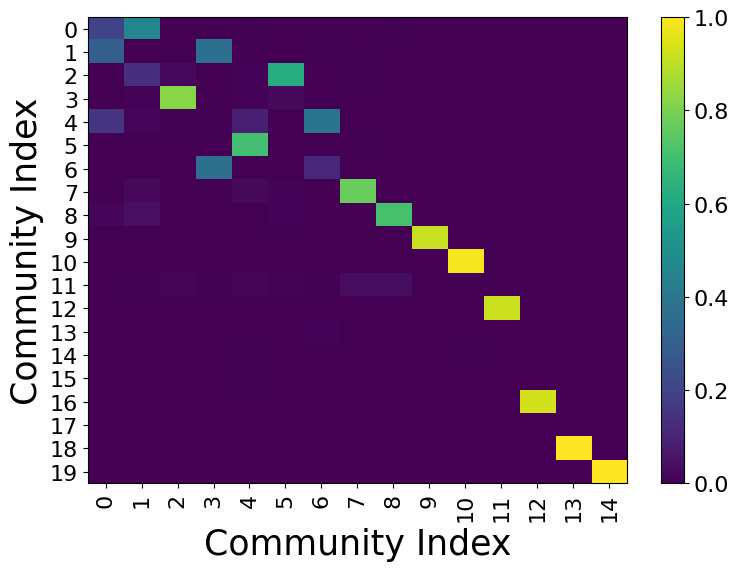

16 15


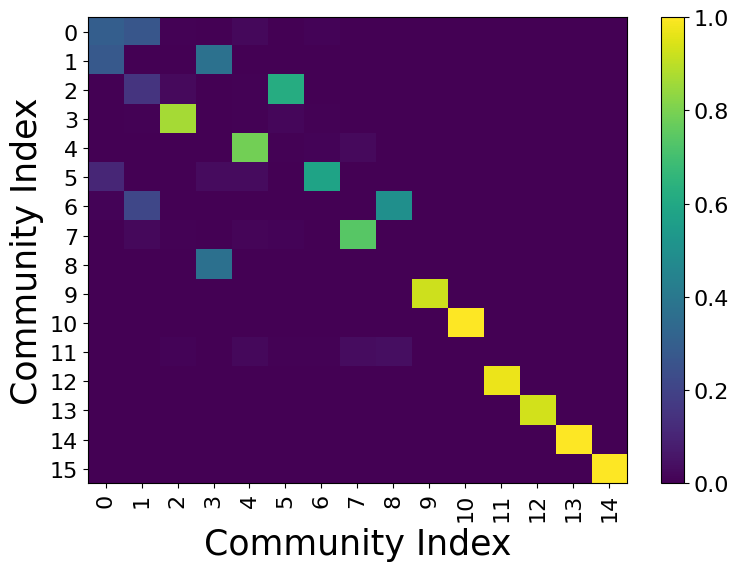

16 15


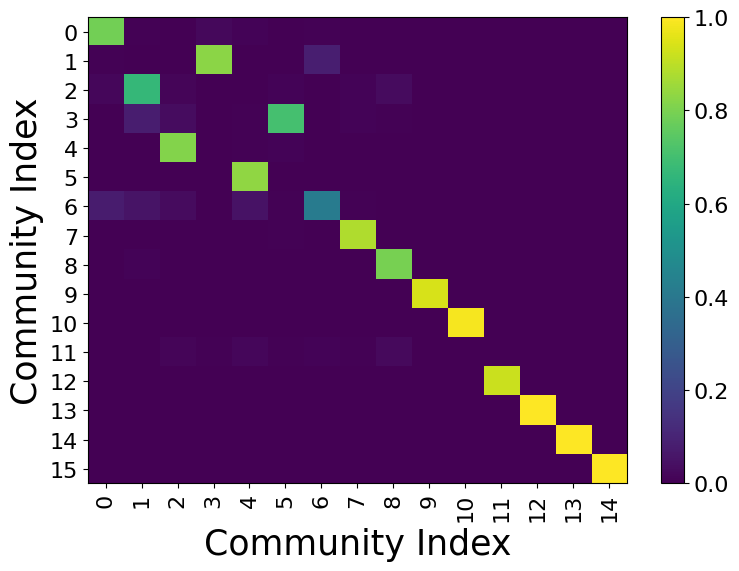

16 15


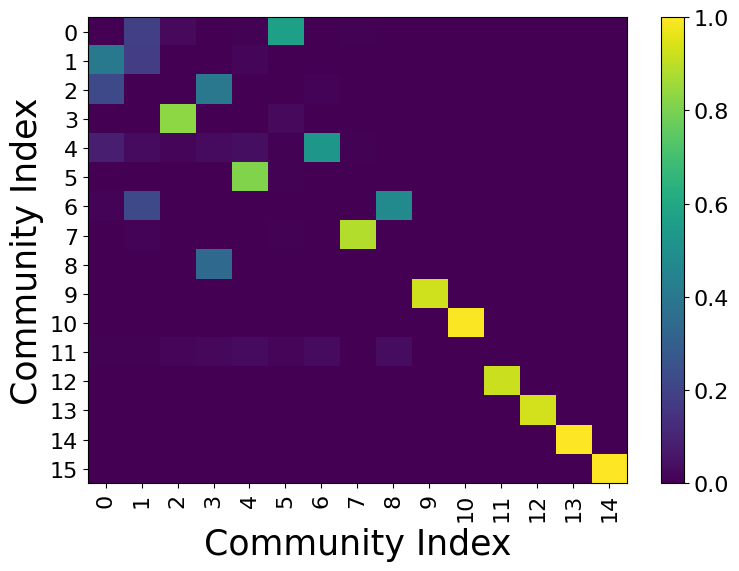

In [35]:
for d in LIST_OF_DISEASES:
    J = community_jaccard_matrix(d, "NONE", save_path=f"../../Graphs/{d}/jaccard_comparison_to_baseline.pdf", show_plot=True, selected=False)

In [36]:
for d in LIST_OF_DISEASES:
    print(mean_best_jaccard(d,"NONE"))

12 11
0.5992585116994593
12 11
0.6134540421256574
12 11
0.7451768644358836
12 11
0.6098757943483627


In [37]:
# # Mean-max jaccard score
# jaccard_scores = []
# l = len(LIST_OF_DISEASES)
# dsm = np.zeros([1,l])
# for i in range(l):
#     d = LIST_OF_DISEASES[i]
#     J = community_jaccard_matrix_selected(d,"NONE",show_plot = False, selected = True)
#     mean_best_jaccard = (J.max(axis=1).sum()) / (J.shape[0])
#     dsm[0,i] = mean_best_jaccard
#     jaccard_scores.append((mean_best_jaccard,i))

# print(dsm)

In [38]:
# plot_heatmap(
#     dsm, 
#     row_labels=["NONE"],
#     col_labels=LIST_OF_DISEASES,
#     vmin=0, 
#     vmax=1,
# )


# Disease comparison

## Community Level

12 12


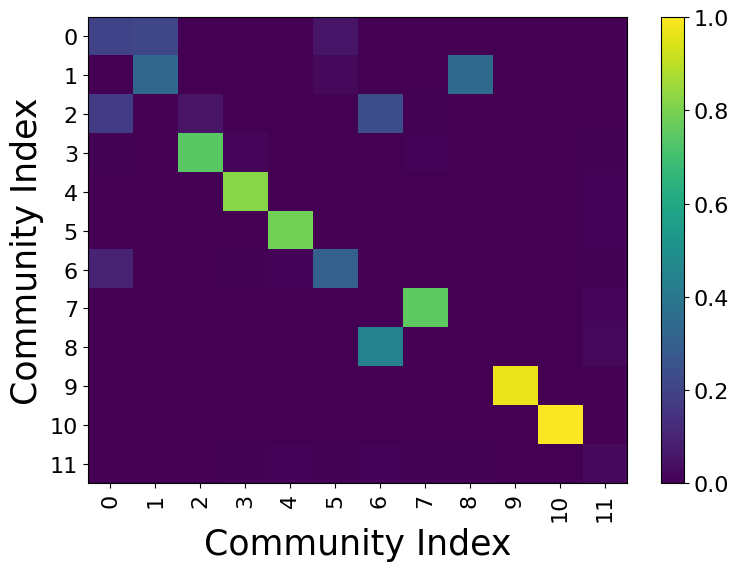

array([[2.00653595e-01, 2.11042945e-01, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 5.56179775e-02, 5.47045952e-04, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.81983621e-03],
       [0.00000000e+00, 3.30152672e-01, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 2.25409836e-02, 0.00000000e+00, 0.00000000e+00,
        3.47631814e-01, 0.00000000e+00, 0.00000000e+00, 8.21692687e-04],
       [1.78378378e-01, 0.00000000e+00, 5.16647532e-02, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 2.39114918e-01, 7.75740480e-03,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [5.61167228e-03, 0.00000000e+00, 7.42354032e-01, 1.36452242e-02,
        2.62743037e-03, 0.00000000e+00, 2.81056773e-03, 9.56937799e-03,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.75737393e-03],
       [5.20562207e-04, 0.00000000e+00, 2.49376559e-03, 8.21929101e-01,
        9.82318271e-04, 0.00000000e+00, 0.00000000e+00, 0.00

In [39]:
community_jaccard_matrix("LEUKEMIA","SCHIZOPHRENIA", show_plot=True, selected=True)

BIPOLAR SCHIZOPHRENIA
12 12


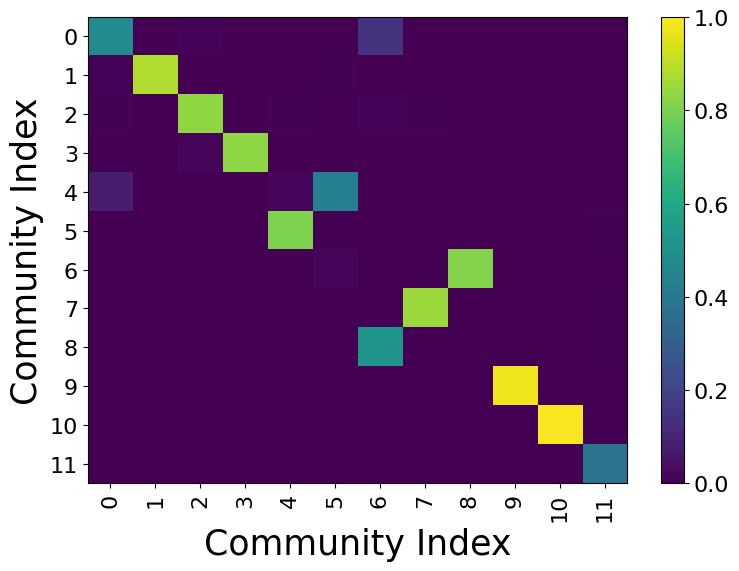

BIPOLAR LEUKEMIA
12 12


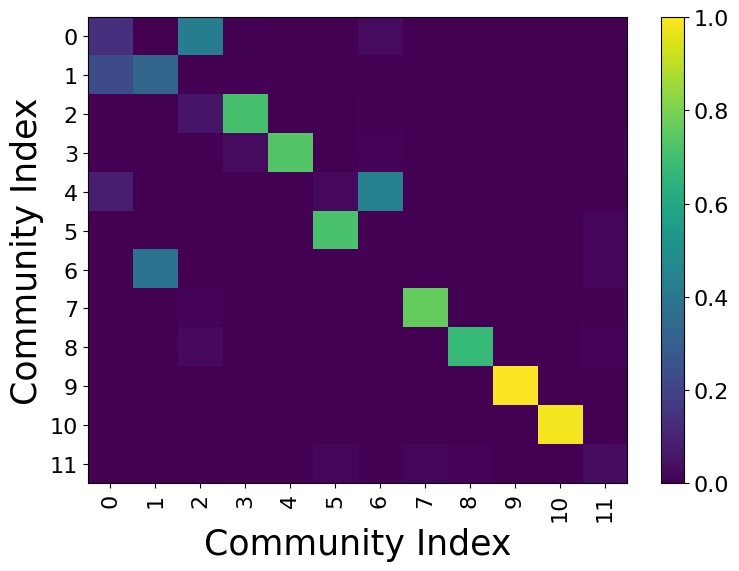

BIPOLAR BREASTCANCER
12 12


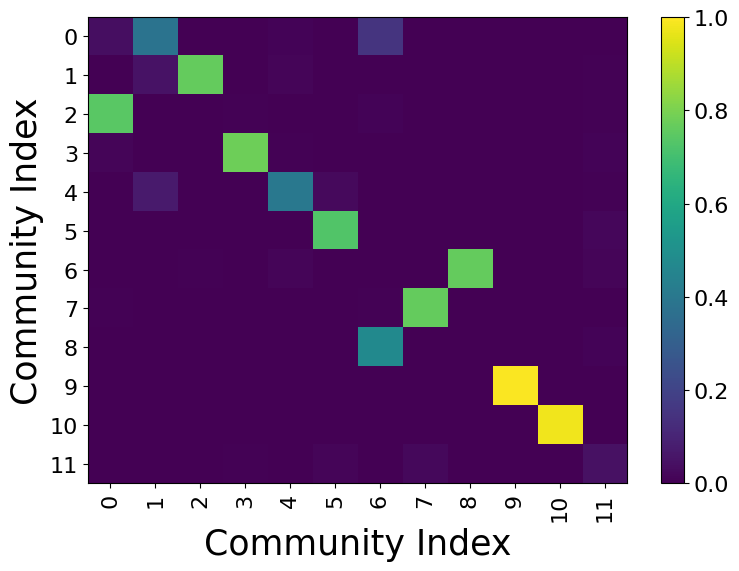

SCHIZOPHRENIA LEUKEMIA
12 12


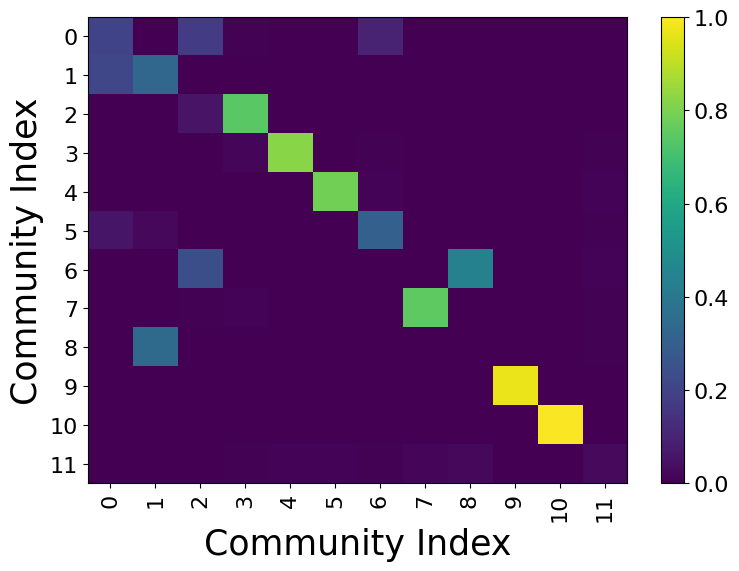

SCHIZOPHRENIA BREASTCANCER
12 12


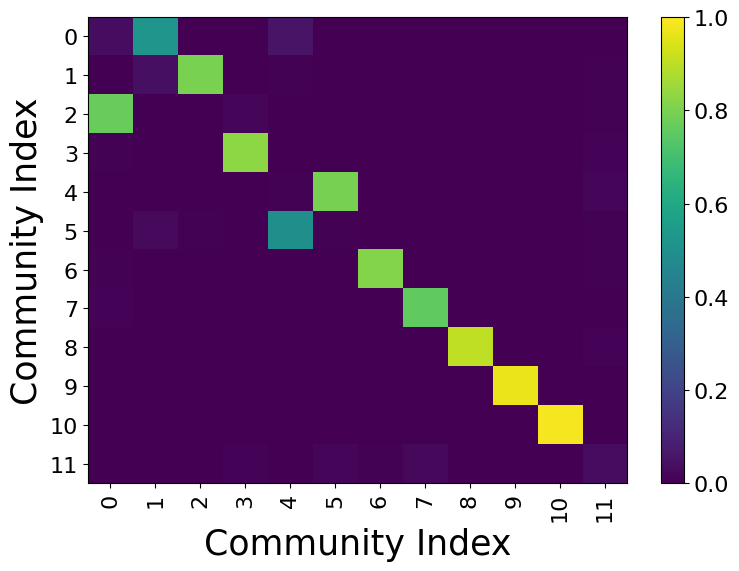

LEUKEMIA BREASTCANCER
12 12


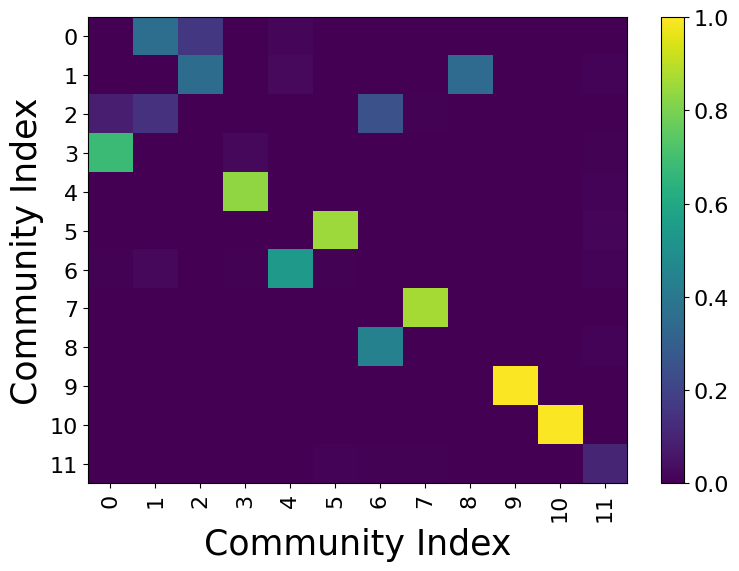

In [40]:
for d1,d2 in combinations(LIST_OF_DISEASES,2):
    print(d1,d2)
    community_jaccard_matrix(d1,d2, save_path = f"../../Graphs/pairwise_disease_community_comparison/comparison_{d1}_{d2}.pdf",show_plot = True)
    

## Disease Level

In [41]:
# Mean-max jaccard score
jaccard_scores = []
l = len(LIST_OF_DISEASES)
dsm = np.zeros([l,l])
np.fill_diagonal(dsm, 1)
for i,j in combinations(range(l), 2):
    d1,d2 = LIST_OF_DISEASES[i],LIST_OF_DISEASES[j]
    dsm[i,j] = mean_best_jaccard(d1,d2)
    jaccard_scores.append((mean_best_jaccard,i,j))
    
# symmetrize
dsm = dsm + dsm.T
np.fill_diagonal(dsm, 1)

print(dsm)

12 12
12 12
12 12
12 12
12 12
12 12
[[1.         0.73282509 0.59263561 0.65161   ]
 [0.73282509 1.         0.556216   0.72315237]
 [0.59263561 0.556216   1.         0.60963162]
 [0.65161    0.72315237 0.60963162 1.        ]]


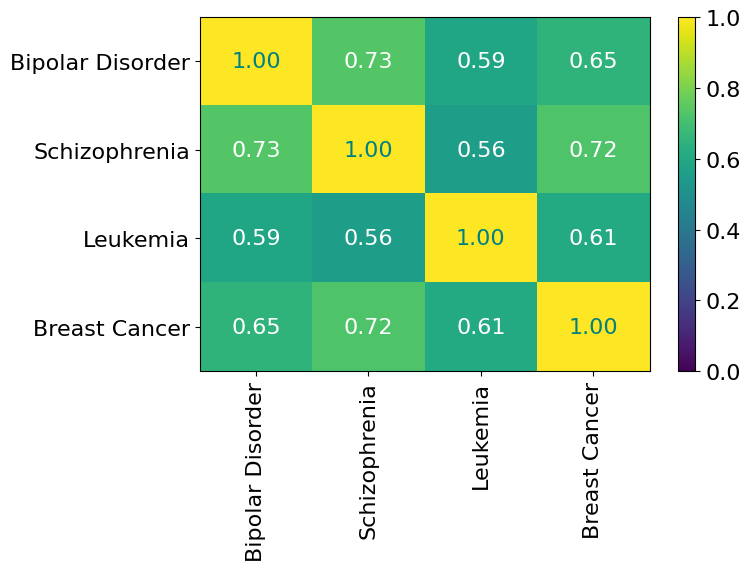

In [42]:
plot_heatmap(
    dsm, 
    row_labels=LIST_OF_DISEASES_LABEL,
    col_labels=LIST_OF_DISEASES_LABEL,
    vmin=0, 
    vmax=1,
    save_path= "../../Graphs/disease_similarity_heatmap_4.pdf",
    show_label=False
)


In [43]:
# # Max jaccard score
# jaccard_scores = []
# l = len(LIST_OF_DISEASES_CLEAN)
# dsm_max = np.zeros([l,l])
# np.fill_diagonal(dsm_max, 1)
# for i,j in combinations(range(l), 2):
#     d1,d2 = LIST_OF_DISEASES_CLEAN[i],LIST_OF_DISEASES_CLEAN[j]
#     J = community_jaccard_matrix_selected(d1,d2,show_plot = False, selected = True)
#     best_jaccard = J.max()
#     dsm_max[i,j] = best_jaccard
#     jaccard_scores.append((mean_best_jaccard,i,j))
    
# # symmetrize
# dsm_max = dsm_max + dsm_max.T
# np.fill_diagonal(dsm_max, 1)

# print(dsm_max)